## Notebook 2: Handwritten Digit Recognition (Softmax / CrossEntropy)

In [1]:
# CELL 1 — Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
# CELL 2 — Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean/std
])

train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

Train samples: 60000 | Test samples: 10000


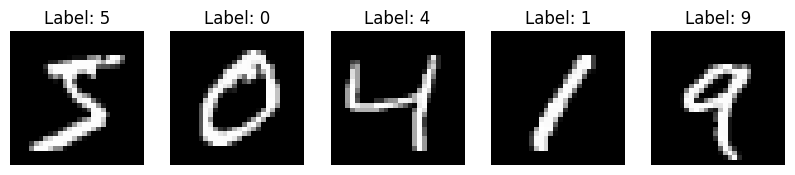

In [3]:
# CELL 3 — Visualize a few samples
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    img, label = train_dataset[i]
    axes[i].imshow(img.squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")
plt.show()

In [4]:
# CELL 4 — Model definition
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)  # raw logits — NOT passed through softmax here
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

model = DigitClassifier().to(device)
criterion = nn.CrossEntropyLoss()  # applies softmax + NLL internally, numerically stable
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(model)

DigitClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [5]:
# CELL 5 — Training loop
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} — Avg Loss: {avg_loss:.4f}")

Epoch 1/5 — Avg Loss: 0.2645
Epoch 2/5 — Avg Loss: 0.1110
Epoch 3/5 — Avg Loss: 0.0780
Epoch 4/5 — Avg Loss: 0.0611
Epoch 5/5 — Avg Loss: 0.0489


In [6]:
# CELL 6 — Evaluation
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1)   # apply softmax manually for interpretation
        preds = torch.argmax(probs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 97.58%


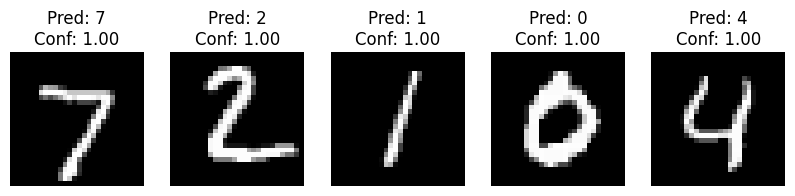

In [7]:
# CELL 7 — Inspect predictions with softmax probabilities
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    logits = model(images[:5])
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axes[i].imshow(images[i].cpu().squeeze(), cmap="gray")
    axes[i].set_title(f"Pred: {preds[i].item()}\nConf: {probs[i][preds[i]].item():.2f}")
    axes[i].axis("off")
plt.show()